11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Epoch 1: D Loss=0.3609, G Loss=1.7880
Epoch 2: D Loss=0.5061, G Loss=2.0084
Epoch 3: D Loss=0.4958, G Loss=2.1855
Epoch 4: D Loss=0.4257, G Loss=2.0267
Epoch 5: D Loss=0.3663, G Loss=2.1415
Epoch 6: D Loss=1.2481, G Loss=1.3055
Epoch 7: D Loss=0.9762, G Loss=1.5496
Epoch 8: D Loss=0.6880, G Loss=1.8090
Epoch 9: D Loss=0.3098, G Loss=2.4197
Epoch 10: D Loss=0.4667, G Loss=3.0370


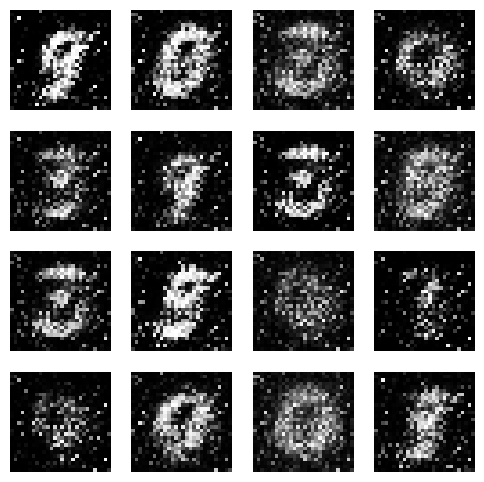

In [ ]:
# ==============================
# SIMPLE GAN ON MNIST (COLAB)
# ==============================

import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt

# 1. Load Dataset
(x_train, _), (_, _) = keras.datasets.mnist.load_data()

# 2. Preprocess Data
x_train = x_train.astype("float32")
x_train = (x_train - 127.5) / 127.5
x_train = x_train.reshape(x_train.shape[0], 28, 28, 1)

# 3. Parameters
batch_size = 64
noise_dim = 100
epochs = 10

# 4. Dataset batching
dataset = tf.data.Dataset.from_tensor_slices(x_train).shuffle(60000).batch(batch_size)

# 5. Generator
generator = keras.Sequential([
    keras.layers.Input(shape=(noise_dim,)),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(28 * 28 * 1, activation='tanh'),
    keras.layers.Reshape((28, 28, 1))
])

# 6. Discriminator
discriminator = keras.Sequential([
    keras.layers.Input(shape=(28, 28, 1)),
    keras.layers.Flatten(),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(1, activation='sigmoid')
])

# 7. Loss and Optimizers
loss_fn = keras.losses.BinaryCrossentropy()
g_optimizer = keras.optimizers.Adam(0.0002)
d_optimizer = keras.optimizers.Adam(0.0002)

# 8. Training Loop
for epoch in range(epochs):
    for real_images in dataset:

        batch_size_now = real_images.shape[0]

        real_labels = tf.ones((batch_size_now, 1))
        fake_labels = tf.zeros((batch_size_now, 1))

        # ---- Train Discriminator ----
        noise = tf.random.normal((batch_size_now, noise_dim))
        fake_images = generator(noise, training=True)

        with tf.GradientTape() as tape:
            real_output = discriminator(real_images, training=True)
            fake_output = discriminator(fake_images, training=True)

            real_loss = loss_fn(real_labels, real_output)
            fake_loss = loss_fn(fake_labels, fake_output)
            d_loss = real_loss + fake_loss

        grads = tape.gradient(d_loss, discriminator.trainable_variables)
        d_optimizer.apply_gradients(zip(grads, discriminator.trainable_variables))

        # ---- Train Generator ----
        noise = tf.random.normal((batch_size_now, noise_dim))

        with tf.GradientTape() as tape:
            generated_images = generator(noise, training=True)
            output = discriminator(generated_images, training=True)

            g_loss = loss_fn(real_labels, output)

        grads = tape.gradient(g_loss, generator.trainable_variables)
        g_optimizer.apply_gradients(zip(grads, generator.trainable_variables))

    print(f"Epoch {epoch+1}: D Loss={d_loss.numpy():.4f}, G Loss={g_loss.numpy():.4f}")

# 9. Generate Images
noise = tf.random.normal((16, noise_dim))
generated_images = generator(noise, training=False)

# 10. Display
fig, axes = plt.subplots(4, 4, figsize=(6, 6))
for i, ax in enumerate(axes.flat):
    ax.imshow((generated_images[i, :, :, 0] + 1) / 2, cmap='gray')
    ax.axis('off')

plt.show()